# Tangent Plane Approximation

This notebook derives/tests the tangent plane approximation for celestial coordinates. Given a reference point $\alpha_0, \delta_0$ on the celestial sphere, we would like to write nearby points $\alpha, \delta$ in terms of Cartesian coordinates $x, y$ on a plane tangent to the sphere at the reference point. We also want to include a possible rotation by a position angle $\theta$.

We proceed as follows:

1. Rotate the reference point to the North Pole. We do this by first rotating by $-\alpha_0$ in RA (about the z-axis), then by $-(\pi/2 - \delta_0)$ in Dec (about the y-axis). We'll do this using rotation matrices in 3D, but with the simplification that the first rotation is nothing but a shift in RA, so we can just add it to the RA of all points.
2. Do the same to the points $\alpha, \delta$ to get the 3D Cartesian coordinates $x,y,z$.
3. Project these points onto the tangent plane with $x/z, y/z$.

Note that this last division by $z$ accounts for the curvature of the sphere, and the projection onto the actual tangent plane.

4. Finally, apply a rotation by the position angle $\theta$ (East of North) to get the final $x,y$ coordinates.

In [1]:

import numpy as np

## Step 1: Spherical to Cartesian

Convert $(\alpha, \delta)$ to 3D Cartesian coordinates on the unit sphere:

$$
\begin{pmatrix} x \\ y \\ z \end{pmatrix}
= \begin{pmatrix} \cos\delta \cos\alpha \\ \cos\delta \sin\alpha \\ \sin\delta \end{pmatrix}
$$

## Step 2: Rotate the reference point to the North Pole

We apply two rotations:

1. **Rotate in RA** by $-\alpha_0$ (about the z-axis). This is equivalent to replacing $\alpha \to \alpha - \alpha_0$ before converting to Cartesian, so we fold it into the conversion step.

2. **Rotate in Dec** by $-(\pi/2 - \delta_0)$ about the y-axis to bring the reference point to the pole. The rotation matrix is:

$$
R_y(\theta) = \begin{pmatrix}
\cos\theta & 0 & \sin\theta \\
0 & 1 & 0 \\
-\sin\theta & 0 & \cos\theta
\end{pmatrix}
$$

where $\theta = -(\pi/2 - \delta_0) = \delta_0 - \pi/2$.

You can verify that applying this to the reference point $(\cos\delta_0, 0, \sin\delta_0)$ (after the RA shift makes its RA zero) gives $(0, 0, 1)$, i.e. the North Pole.

## Step 3: Gnomonic (tangent plane) projection

Once the reference point is at the pole, nearby points have $z \approx 1$. The gnomonic projection onto the tangent plane at the pole divides by $z$. However, we need to be careful about which 3D axis maps to which tangent-plane direction.

The y-axis rotation (Step 2b) only mixes $x$ and $z$, leaving $y$ unchanged. So after the rotation:

- $y_r$ still points in the original $y$ direction, which is the **East** (increasing RA) direction.
- $x_r$ lies in the original $x$-$z$ plane, perpendicular to both $z_r$ (our new pole) and $y_r$. It points in the **-Dec** (South) direction.

Therefore, to get tangent-plane coordinates with $\xi$ = East and $\eta$ = North:

$$
\xi = y_r / z_r, \quad \eta = -x_r / z_r
$$

## Step 4: Position angle and focal plane rotation

Since $x$ = East points left in the standard sky orientation, the rotation matrix that takes North toward East is:

$$
R(\theta) = \begin{pmatrix}
\cos\theta & \sin\theta \\
-\sin\theta & \cos\theta
\end{pmatrix}
$$

You can verify: for $\theta = 90°$, a North vector $(\xi, \eta) = (0, 1)$ maps to $(1, 0)$ = East. $\checkmark$

The total orientation of the FPA on the sky is $\text{PA} + \theta_{\text{focal}}$, where PA is the telescope position angle and $\theta_{\text{focal}}$ is the fixed rotation of the focal plane relative to the telescope (e.g. $-60°$ for our instrument). To transform **from** sky coordinates **into** the focal plane frame, we apply the inverse rotation:

$$
\theta = -(\text{PA} + \theta_{\text{focal}})
$$

$$
\begin{pmatrix} x' \\ y' \end{pmatrix}
= R\bigl(-(\text{PA} + \theta_{\text{focal}})\bigr)
\begin{pmatrix} \xi \\ \eta \end{pmatrix}
$$

For example, at $\text{PA} = 60°$ and $\theta_{\text{focal}} = -60°$, the total sky orientation is $0°$, so the inverse rotation is also $0°$ and the FPA is aligned with the sky axes.

In [2]:


def tangent_plane(ra, dec, pointing_ra, pointing_dec, pointing_pa=0.0, focal_pa=-60.0):
    """Project (ra, dec) onto a tangent plane at a reference pointing.

    Uses the gnomonic (tangent-plane) projection with an optional
    position-angle rotation and focal plane rotation.

    Parameters
    ----------
    ra, dec : array_like
        Right ascension and declination of the source(s) in degrees.
    pointing_ra, pointing_dec : float
        Reference point (field center) in degrees.
    pointing_pa : float, optional
        Position angle in degrees, measured East of North (default 0).
    focal_pa : float, optional
        Physical orientation of the focal plane coordinate system in
        degrees, measured East of North relative to the telescope
        (default -60).  For example, -60 means the focal plane axes
        are rotated 60° West of the telescope's V3 axis.  The total
        sky orientation is PA + focal_pa; the code applies the inverse
        rotation -(PA + focal_pa) to transform sky coordinates into
        the focal plane frame.

    Returns
    -------
    x, y : ndarray
        Focal-plane coordinates in degrees.  With PA=0 and focal_pa=0,
        x points East and y points North.
    """
    # Convert everything to radians
    ra_rad = np.deg2rad(np.asarray(ra, dtype=float))
    dec_rad = np.deg2rad(np.asarray(dec, dtype=float))
    ra0 = np.deg2rad(pointing_ra)
    dec0 = np.deg2rad(pointing_dec)
    pa = np.deg2rad(-(pointing_pa + focal_pa))

    # ------------------------------------------------------------------
    # Step 1 + 2a: Shift RA so the reference point is at RA = 0,
    # then convert to 3D Cartesian coordinates on the unit sphere.
    # ------------------------------------------------------------------
    da = ra_rad - ra0  # relative RA
    cos_dec = np.cos(dec_rad)
    x = cos_dec * np.cos(da)
    y = cos_dec * np.sin(da)
    z = np.sin(dec_rad)

    # ------------------------------------------------------------------
    # Step 2b: Rotate about the y-axis by angle = dec0 - pi/2
    # to bring the reference point (which is now at dec=dec0, RA=0)
    # to the North Pole.
    #
    # The rotation angle is  theta_y = dec0 - pi/2, so:
    #   cos(theta_y) =  cos(dec0 - pi/2) =  sin(dec0)
    #   sin(theta_y) =  sin(dec0 - pi/2) = -cos(dec0)
    # ------------------------------------------------------------------
    sin_dec0 = np.sin(dec0)
    cos_dec0 = np.cos(dec0)

    # Apply R_y(dec0 - pi/2):
    #   x' =  cos(theta_y) * x + sin(theta_y) * z =  sin(dec0)*x - cos(dec0)*z
    #   y' =  y                                     (unchanged)
    #   z' = -sin(theta_y) * x + cos(theta_y) * z =  cos(dec0)*x + sin(dec0)*z
    xr = sin_dec0 * x - cos_dec0 * z
    yr = y
    zr = cos_dec0 * x + sin_dec0 * z

    # ------------------------------------------------------------------
    # Step 3: Gnomonic projection onto the tangent plane at the pole.
    # The y-axis rotation leaves yr pointing East, and xr points -Dec.
    # So to get xi=East, eta=North:
    #   xi  =  yr / zr   (East)
    #   eta = -xr / zr   (North)
    # ------------------------------------------------------------------
    xi = yr / zr
    eta = -xr / zr

    # ------------------------------------------------------------------
    # Step 4: Rotate by -(PA + focal_pa).
    # The FPA is oriented at (PA + focal_pa) on the sky. To transform
    # from sky to FPA, we apply the inverse: -(PA + focal_pa).
    # The matrix [cos, sin; -sin, cos] rotates N toward E for positive
    # angles.
    # ------------------------------------------------------------------
    cos_pa = np.cos(pa)
    sin_pa = np.sin(pa)
    x_out = cos_pa * xi + sin_pa * eta
    y_out = -sin_pa * xi + cos_pa * eta

    # Convert from radians to degrees
    return np.rad2deg(x_out), np.rad2deg(y_out)

## Quick test

Place a few points near a reference and check that the projection makes sense:

- A point offset in Dec only should appear along the y-axis (before PA rotation).
- A point offset in RA only should appear along the x-axis.
- Small offsets should be approximately equal to the angular separation in degrees.

In [3]:

# Reference pointing
ra0, dec0 = 180.0, 45.0  # degrees

# Test points: small offsets in RA and Dec
offset_deg = 0.1  # 0.1 degree ~ 6 arcmin
test_ra = np.array([ra0, ra0 + offset_deg, ra0 - offset_deg, ra0])
test_dec = np.array([dec0 + offset_deg, dec0, dec0, dec0 - offset_deg])

x, y = tangent_plane(test_ra, test_dec, ra0, dec0, pointing_pa=0.0, focal_pa=0.0)

print("Tangent plane coordinates (degrees):")
print(f"  Expected offset ≈ {offset_deg:.6f} deg")
for i in range(len(test_ra)):
    print(f"  Point {i}: (x={x[i]:+.6f}, y={y[i]:+.6f})")

Tangent plane coordinates (degrees):
  Expected offset ≈ 0.100000 deg
  Point 0: (x=+0.000000, y=+0.100000)
  Point 1: (x=+0.070711, y=+0.000044)
  Point 2: (x=-0.070711, y=+0.000044)
  Point 3: (x=+0.000000, y=-0.100000)


In [4]:

# Test with a 90-degree position angle rotation (no focal offset):
# PA=90 means the FPA is rotated 90° E of N on the sky.
# To transform sky->FPA we apply -90°, so N->W, E->N in FPA coords.
x90, y90 = tangent_plane(test_ra, test_dec, ra0, dec0, pointing_pa=90.0, focal_pa=0.0)

print("\nWith PA = 90 deg:")
for i in range(len(test_ra)):
    print(f"  Point {i}: (x={x90[i]:+.6f}, y={y90[i]:+.6f})")


With PA = 90 deg:
  Point 0: (x=-0.100000, y=+0.000000)
  Point 1: (x=-0.000044, y=+0.070711)
  Point 2: (x=-0.000044, y=-0.070711)
  Point 3: (x=+0.100000, y=-0.000000)



## Comparison to existing code in optical model

The existing optical model code uses a flat-sky approximation with a confusing angle construction. Let's unpack it.

The old `get_pa_rotation` computes `theta = pa + 180 - 60`, applies a rotation matrix $R(\theta)$, then negates both output components. Negating a 2D vector is the same as rotating by 180°, so the net rotation is:

$$R_{\text{net}} = -R(\text{pa} + 180 - 60) = R(\text{pa} + 180 - 60 + 180) = R(\text{pa} - 60)$$

The +180 in the angle and the negation cancel out completely. The old code is just applying $R(\text{pa} - 60)$.

The old code's rotation matrix $[\cos, -\sin; \sin, \cos]$ is the standard math convention, which rotates North toward West in our left-handed sky coordinate system ($x$ = East = left). Our matrix $[\cos, \sin; -\sin, \cos]$ correctly rotates North toward East. The old code's $R(\text{pa} - 60)$ with N→W is equivalent to our $R(-(pa-60))$ = $R(60 - \text{pa})$ = $R(-(\text{pa} + (-60)))$ = $R(-(\text{PA} + \text{focal\_pa}))$, which is exactly our formula. So the two codes should agree at all PA values.

Let's verify at the equator where the flat-sky approximation is exact.

In [5]:

# Old code (fixed: removed stray 'self' parameter)
def calculate_fpa_pos(
    ra, dec, pointing_ra, pointing_dec, pointing_pa
):
    """Old flat-sky FPA position calculation."""
    ra, dec = np.atleast_1d(ra), np.atleast_1d(dec)

    dx = (ra - pointing_ra) * np.cos(np.deg2rad(dec))
    dy = dec - pointing_dec
    xy = np.vstack([dx, dy])

    rot_matrix = get_pa_rotation(pa=pointing_pa)
    xy = rot_matrix @ xy

    xfpa = -xy[0, :]
    yfpa = -xy[1, :]

    return xfpa, yfpa

def get_pa_rotation(pa):
    """Old rotation matrix (pa + 180 - 60)."""
    theta = np.deg2rad(pa + 180 - 60)
    return np.array(
        [
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta), np.cos(theta)],
        ]
    )

In [6]:

# Compare at the equator where flat-sky ≈ gnomonic
ra0_eq, dec0_eq = 180.0, 0.0
test_ra_eq = np.array([ra0_eq, ra0_eq + 0.1, ra0_eq, ra0_eq - 0.1])
test_dec_eq = np.array([dec0_eq + 0.1, dec0_eq, dec0_eq - 0.1, dec0_eq])

for pa_test in [0.0, 45.0, 90.0]:
    x_new, y_new = tangent_plane(test_ra_eq, test_dec_eq, ra0_eq, dec0_eq,
                                  pointing_pa=pa_test, focal_pa=-60.0)
    x_old, y_old = calculate_fpa_pos(test_ra_eq, test_dec_eq, ra0_eq, dec0_eq,
                                      pointing_pa=pa_test)
    print(f"PA = {pa_test}°:")
    print(f"  New: x={x_new}, y={y_new}")
    print(f"  Old: x={x_old}, y={y_old}")
    print(f"  Diff: dx={x_new - x_old}, dy={y_new - y_old}")
    print()

PA = 0.0°:
  New: x=[ 0.08660263  0.05000005 -0.08660263 -0.05000005], y=[ 0.05000005 -0.08660263 -0.05000005  0.08660263]
  Old: x=[ 0.08660254  0.05       -0.08660254 -0.05      ], y=[ 0.05       -0.08660254 -0.05        0.08660254]
  Diff: dx=[ 8.79355818e-08  5.07696316e-08 -8.79355818e-08 -5.07696316e-08], dy=[ 5.07696319e-08 -8.79355813e-08 -5.07696319e-08  8.79355813e-08]

PA = 45.0°:
  New: x=[ 0.02588193  0.09659268 -0.02588193 -0.09659268], y=[ 0.09659268 -0.02588193 -0.09659268  0.02588193]
  Old: x=[ 0.0258819   0.09659258 -0.0258819  -0.09659258], y=[ 0.09659258 -0.0258819  -0.09659258  0.0258819 ]
  Diff: dx=[ 2.62802952e-08  9.80793966e-08 -2.62802952e-08 -9.80793966e-08], dy=[ 9.80793972e-08 -2.62802951e-08 -9.80793972e-08  2.62802951e-08]

PA = 90.0°:
  New: x=[-0.05000005  0.08660263  0.05000005 -0.08660263], y=[ 0.08660263  0.05000005 -0.08660263 -0.05000005]
  Old: x=[-0.05        0.08660254  0.05       -0.08660254], y=[ 0.08660254  0.05       -0.08660254 -0.05     

## Visual test: FPA footprint on the sky

Lay down a grid of points on the sky, transform to focal plane coordinates, select those that fall within the FPA bounds ($x \in [-0.4, 0.4]$, $y \in [-0.3, 0.2]$), and plot them back in RA/Dec colored by FPA quadrant. This makes the rotation and projection visually obvious.

In [7]:

import matplotlib.pyplot as plt

def plot_fpa_footprint(pointing_ra, pointing_dec, pointing_pa, ax_new, ax_old):
    """Plot FPA footprint on sky for both new and old code."""
    # Dense grid of sky points around the pointing center
    ra_grid = np.linspace(pointing_ra - 1.0, pointing_ra + 1.0, 500)
    dec_grid = np.linspace(pointing_dec - 1.0, pointing_dec + 1.0, 500)
    ra_mesh, dec_mesh = np.meshgrid(ra_grid, dec_grid)
    ra_flat = ra_mesh.ravel()
    dec_flat = dec_mesh.ravel()

    # FPA bounds (asymmetric in y, matching the WFI layout)
    x_lo, x_hi = -0.4, 0.4
    y_lo, y_hi = -0.3, 0.2

    # --- New code ---
    xn, yn = tangent_plane(ra_flat, dec_flat, pointing_ra, pointing_dec,
                           pointing_pa=pointing_pa, focal_pa=-60.0)
    in_fpa_new = (xn >= x_lo) & (xn <= x_hi) & (yn >= y_lo) & (yn <= y_hi)

    # Assign quadrant colors: (+x,+y)=0, (-x,+y)=1, (-x,-y)=2, (+x,-y)=3
    quad_new = np.where(xn >= 0, np.where(yn >= 0, 0, 3), np.where(yn >= 0, 1, 2))

    quad_labels = ['+x,+y', '−x,+y', '−x,−y', '+x,−y']
    for q, (color, label) in enumerate(zip(['C0', 'C1', 'C2', 'C3'], quad_labels)):
        mask = in_fpa_new & (quad_new == q)
        ax_new.plot(ra_flat[mask], dec_flat[mask], '.', color=color, ms=1, alpha=0.5,
                    label=label)

    ax_new.legend(markerscale=10, loc='upper right', fontsize='small')
    ax_new.set_xlabel('RA (deg)')
    ax_new.set_ylabel('Dec (deg)')
    ax_new.set_title(f'New code (PA={pointing_pa}°)')
    ax_new.set_aspect('equal')
    ax_new.invert_xaxis()  # East left

    # --- Old code ---
    xo, yo = calculate_fpa_pos(ra_flat, dec_flat, pointing_ra, pointing_dec,
                                pointing_pa=pointing_pa)
    in_fpa_old = (xo >= x_lo) & (xo <= x_hi) & (yo >= y_lo) & (yo <= y_hi)

    quad_old = np.where(xo >= 0, np.where(yo >= 0, 0, 3), np.where(yo >= 0, 1, 2))

    for q, (color, label) in enumerate(zip(['C0', 'C1', 'C2', 'C3'], quad_labels)):
        mask = in_fpa_old & (quad_old == q)
        ax_old.plot(ra_flat[mask], dec_flat[mask], '.', color=color, ms=1, alpha=0.5,
                    label=label)

    ax_old.legend(markerscale=10, loc='upper right', fontsize='small')
    ax_old.set_xlabel('RA (deg)')
    ax_old.set_ylabel('Dec (deg)')
    ax_old.set_title(f'Old code (PA={pointing_pa}°)')
    ax_old.set_aspect('equal')
    ax_old.invert_xaxis()  # East left

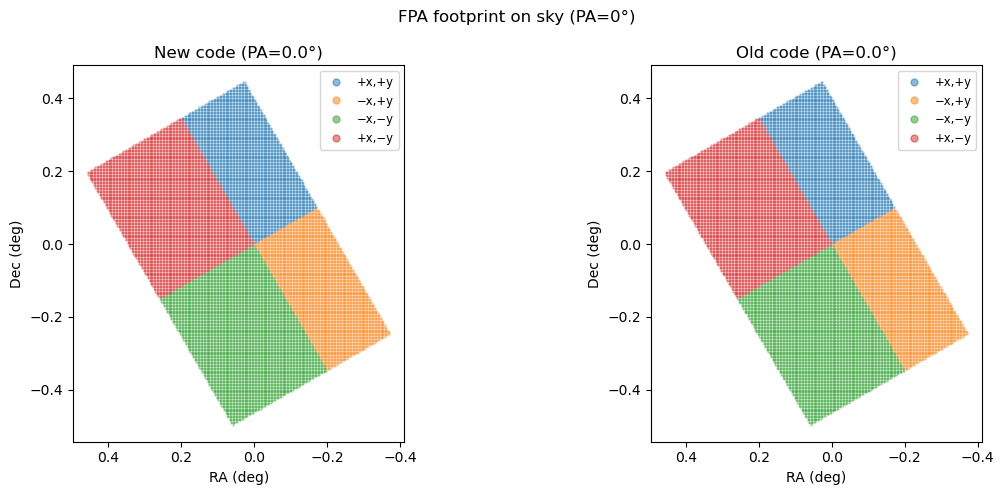

In [8]:

# PA = 0
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_fpa_footprint(0.0, 0.0, 0.0, ax1, ax2)
fig.suptitle('FPA footprint on sky (PA=0°)')
fig.tight_layout()
plt.show()

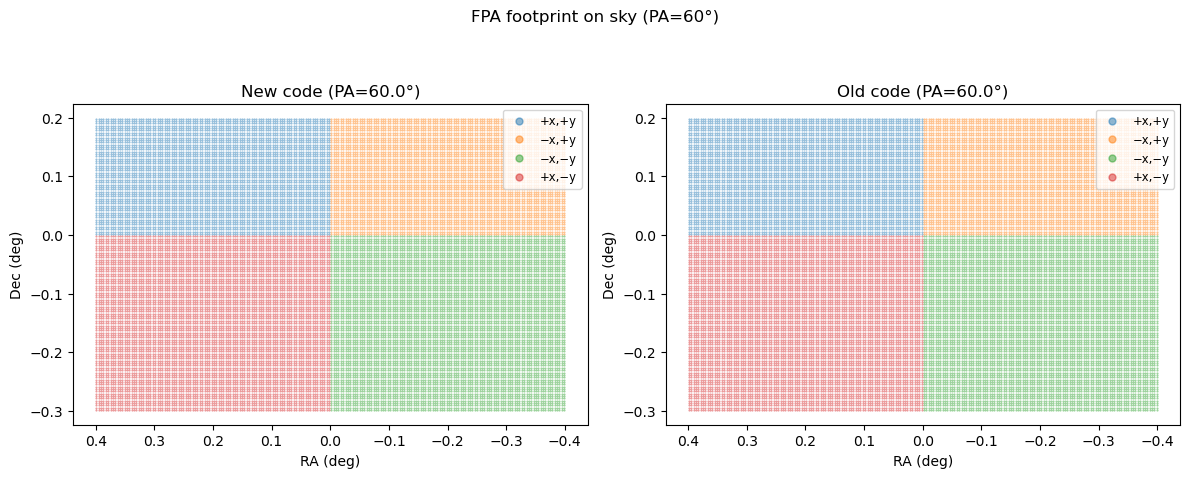

In [9]:

# PA = 60
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_fpa_footprint(0.0, 0.0, 60.0, ax1, ax2)
fig.suptitle('FPA footprint on sky (PA=60°)')
fig.tight_layout()
plt.show()

## Flat-sky vs gnomonic: distortions at high declination

The old code uses a flat-sky approximation ($\Delta x = \Delta\alpha \cos\delta$, $\Delta y = \Delta\delta$) which breaks down away from the equator. Here we compare the two codes at Dec = 0°, 45°, and 85° by distributing points in a 1° region around each pointing (PA = 0) and plotting the displacement vectors (old $-$ new) in FPA coordinates.

In [10]:

def plot_distortion(ra0, dec0, pa=0.0, sky_radius=1.0):
    """Show flat-sky vs gnomonic error for a single pointing.

    Left panel: median and max error vs radial distance from FPA center.
    Right panel: 2D scatter in FPA coordinates colored by error magnitude.
    """
    # Scale RA range by 1/cos(dec) to cover the same physical area
    cos_dec = np.cos(np.deg2rad(dec0))
    ra_half = sky_radius / max(cos_dec, 0.01)
    ra_grid = np.linspace(ra0 - ra_half, ra0 + ra_half, 80)
    dec_grid = np.linspace(dec0 - sky_radius, dec0 + sky_radius, 80)
    ra_mesh, dec_mesh = np.meshgrid(ra_grid, dec_grid)
    ra_flat = ra_mesh.ravel()
    dec_flat = dec_mesh.ravel()

    # New (gnomonic) and old (flat-sky) FPA coordinates
    xn, yn = tangent_plane(ra_flat, dec_flat, ra0, dec0,
                           pointing_pa=pa, focal_pa=-60.0)
    xo, yo = calculate_fpa_pos(ra_flat, dec_flat, ra0, dec0,
                                pointing_pa=pa)

    # Error in arcseconds
    dx = (xo - xn) * 3600
    dy = (yo - yn) * 3600
    mag = np.sqrt(dx**2 + dy**2)

    # Radial distance from FPA center (in degrees)
    r_fpa = np.sqrt(xn**2 + yn**2)

    # Radial bins
    r_max = np.max(r_fpa)
    bin_edges = np.linspace(0, r_max, 25)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_idx = np.digitize(r_fpa, bin_edges) - 1
    bin_idx = np.clip(bin_idx, 0, len(bin_centers) - 1)

    median_err = np.array([np.median(mag[bin_idx == i])
                           if np.any(bin_idx == i) else np.nan
                           for i in range(len(bin_centers))])
    max_err = np.array([np.max(mag[bin_idx == i])
                        if np.any(bin_idx == i) else np.nan
                        for i in range(len(bin_centers))])
    p10 = np.array([np.percentile(mag[bin_idx == i], 10)
                    if np.any(bin_idx == i) else np.nan
                    for i in range(len(bin_centers))])
    p90 = np.array([np.percentile(mag[bin_idx == i], 90)
                    if np.any(bin_idx == i) else np.nan
                    for i in range(len(bin_centers))])

    # --- Plot ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Left: radial profile (log-log)
    ax1.fill_between(bin_centers, p10, p90, alpha=0.2, color='C0',
                     label='10th–90th percentile')
    ax1.plot(bin_centers, median_err, '-', color='C0', label='median')
    ax1.plot(bin_centers, max_err, '--', color='C1', label='max')

    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Distance from FPA center (deg)')
    ax1.set_ylabel('Error (arcsec)')
    ax1.set_title('Error vs radial distance')
    ax1.legend(fontsize='small')

    # Right: 2D scatter
    sc = ax2.scatter(xn, yn, c=mag, s=1, cmap='hot')
    ax2.set_xlabel('FPA x (deg)')
    ax2.set_ylabel('FPA y (deg)')
    ax2.set_title('Error in FPA coordinates')
    ax2.set_aspect('equal')
    plt.colorbar(sc, ax=ax2, label='error (arcsec)')

    # Error at 0.5 deg from FPA center
    mask_05 = (r_fpa >= 0.45) & (r_fpa <= 0.55)
    if np.any(mask_05):
        med_05 = np.median(mag[mask_05])
        max_05 = np.max(mag[mask_05])
        err_str = f'At r=0.5°: median={med_05:.3f}″, max={max_05:.3f}″'
    else:
        err_str = 'No points at r=0.5°'

    print(f"RA={ra0}°, Dec={dec0}°: {err_str}")
    fig.suptitle(f'Flat-sky distortion: RA={ra0}°, Dec={dec0}°, PA={pa}°\n'
                 f'{err_str}')
    fig.tight_layout()
    plt.show()

RA=0.0°, Dec=0.0°: At r=0.5°: median=0.052″, max=0.072″


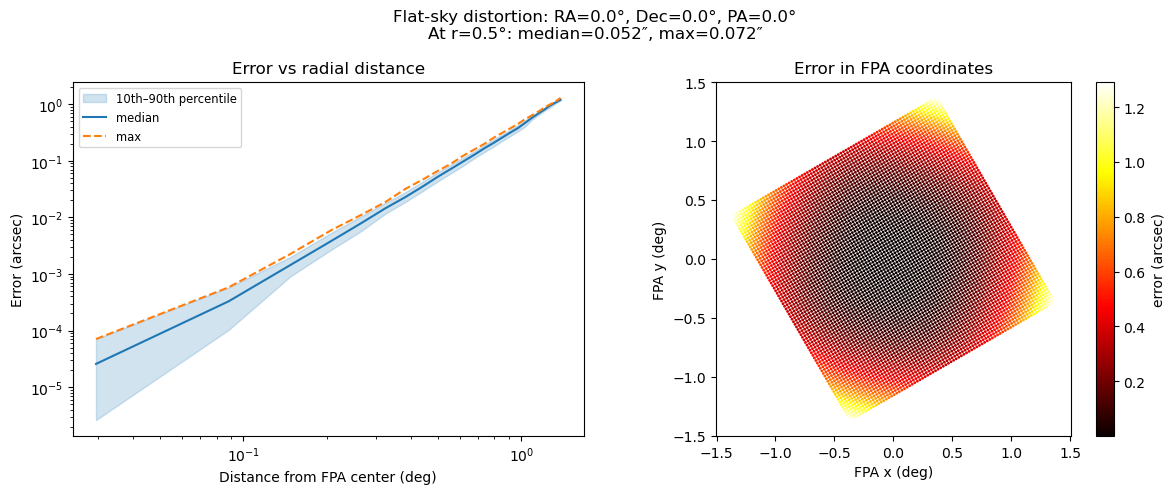

RA=90.0°, Dec=45.0°: At r=0.5°: median=3.696″, max=9.308″


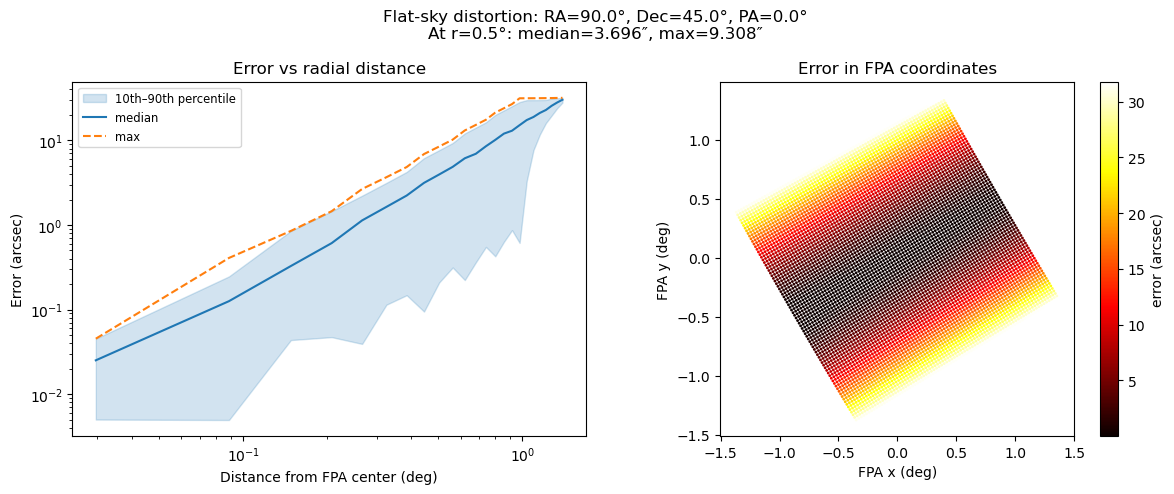

RA=180.0°, Dec=85.0°: At r=0.5°: median=44.966″, max=107.152″


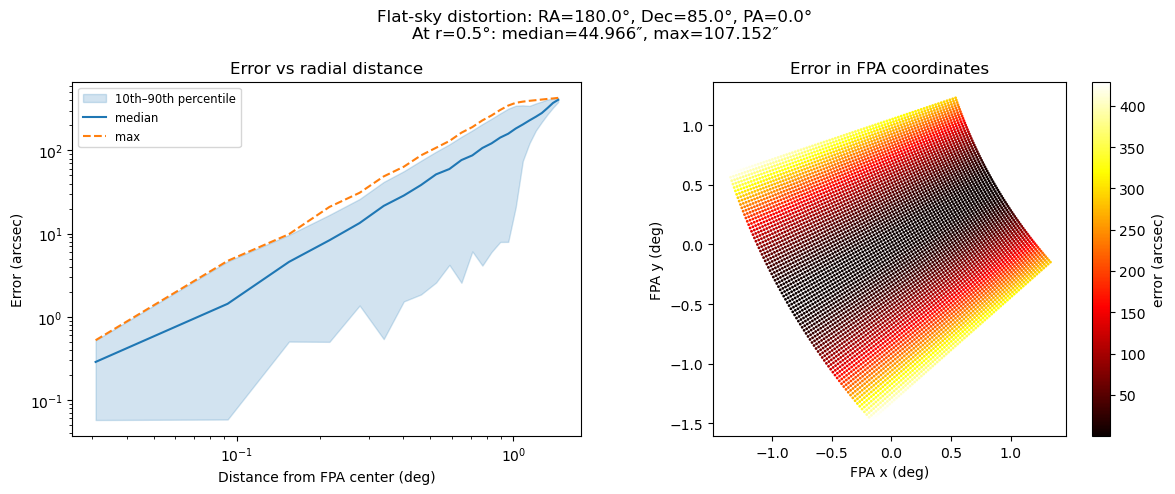

In [11]:

for ra0, dec0 in [(0.0, 0.0), (90.0, 45.0), (180.0, 85.0)]:
    plot_distortion(ra0, dec0, pa=0.0)

## Taylor expansion of the flat-sky error

Why does the error scale as θ³ at the equator but more shallowly at high
declination?  We can answer this by expanding the gnomonic and flat-sky
formulae as Taylor series in the coordinate offsets Δα (in RA) and Δδ.

In [12]:
import sympy as sp
import warnings
warnings.filterwarnings("ignore", message=".*gmpy2.*")

a, d, t = sp.symbols('a d t')         # Δα, Δδ, auxiliary parameter
d0 = sp.Symbol('delta_0')             # reference declination

dec = d0 + d  # declination of the source

# Gnomonic projection (exact)
D = sp.sin(d0)*sp.sin(dec) + sp.cos(d0)*sp.cos(dec)*sp.cos(a)
xi = sp.cos(dec)*sp.sin(a) / D          # East
eta = (sp.cos(d0)*sp.sin(dec) - sp.sin(d0)*sp.cos(dec)*sp.cos(a)) / D  # North

# Flat-sky approximation
x_flat = sp.cos(dec) * a
y_flat = d

# Multivariate Taylor expansion via the parametric trick:
# substitute a -> t*a, d -> t*d, expand in t around 0, then set t = 1.
# This groups terms by total degree in (a, d), i.e. by distance from
# the field center regardless of direction.
subs_t = [(a, t*a), (d, t*d)]

diff_x = sp.series(xi.subs(subs_t) - x_flat.subs(subs_t), t, 0, 4).removeO().subs(t, 1)
diff_y = sp.series(eta.subs(subs_t) - y_flat.subs(subs_t), t, 0, 4).removeO().subs(t, 1)

diff_x = sp.collect(sp.expand(sp.trigsimp(diff_x)), [a, d])
diff_y = sp.collect(sp.expand(sp.trigsimp(diff_y)), [a, d])

print("East error  (ξ − x_flat):")
sp.pprint(diff_x)
print()
print("North error (η − y_flat):")
sp.pprint(diff_y)

East error  (ξ − x_flat):
   ⎛   3              ⎞      2        
 3 ⎜cos (δ₀)   cos(δ₀)⎟   a⋅d ⋅cos(δ₀)
a ⋅⎜──────── - ───────⎟ + ────────────
   ⎝   2          6   ⎠        2      

North error (η − y_flat):
                                3
 2 ⎛d⋅cos(2⋅δ₀)   sin(2⋅δ₀)⎞   d 
a ⋅⎜─────────── + ─────────⎟ + ──
   ⎝     2            4    ⎠   3 


### Interpretation

The leading-order errors (gnomonic minus flat-sky) are:

**East:**
ξ − x = (a³ cos δ₀ / 6)(3 cos²δ₀ − 1) + a d² cos δ₀ / 2

**North:**
η − y = (a² / 4) sin 2δ₀  +  (a² d / 2) cos 2δ₀  +  d³ / 3

Key observations:

- **At the equator (δ₀ = 0):** The East error is a³/3 and the North error
  is d³/3 — pure cubic, giving the θ³/3 scaling we saw in the plots.
- **At high declination:** The North error picks up an a² sin 2δ₀ / 4 term
  that is *second order* in Δα, not third.  This term doesn't depend on Δδ at
  all — it is a purely RA-driven error in the North direction caused by the
  curvature of lines of constant declination.  This is why the error scaling
  becomes shallower than cubic on the log-log plot at high declination.
- **At the poles (δ₀ = 90°):** The a² sin 2δ₀ term vanishes again, and the
  errors return to pure cubic (though the RA coordinate itself is degenerate).
- The worst case for the second-order term is at **δ₀ = 45°**, where
  sin 2δ₀ = 1.